# ตัวอย่างการใช้งาน Batch nom โดยใช้ข้อมูลของ Fashion MNIST
จัดทำโดย อ.ดร.ภูริวัจน์ วรวิชัยพัฒน์

## Batch Normalization คืออะไร?

**Batch Normalization (BN)** คือเทคนิคที่ใช้เพื่อช่วยให้การฝึกโมเดล Deep Neural Network มีความ **รวดเร็ว เสถียร และมีประสิทธิภาพมากขึ้น**
หลักการของ BN คือการ ปรับค่าของแต่ละเลเยอร์ให้มีการกระจายตัวที่เหมาะสม (โดยทั่วไปให้มีค่าเฉลี่ยใกล้ 0 และค่าเบี่ยงเบนมาตรฐานใกล้ 1, zero mean) ระหว่างการฝึกโมเดล

ประโยชน์ของ Batch Normalization:
- ทำให้สามารถใช้ **learning rate ที่สูงขึ้นได้**
- ช่วยลดผลกระทบจากการสุ่มค่าเริ่มต้นของ weight
- ทำให้การฝึกโมเดลมีความ **เสถียรมากขึ้น**
- ช่วยลดการเกิด **overfitting** ได้ในบางกรณี

โดยทั่วไป Batch Normalization จะถูกใช้หลังจากชั้น Dense หรือ Convolution และก่อนการใช้ฟังก์ชัน Activation เช่น ReLU


In [2]:
import tensorflow as tf
import tensorflow.keras as keras

import numpy as np
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

print(tf.config.list_physical_devices())

2.21.0
3.15.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [3]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()
train_images = train_images.astype(np.float32) / 255.0
test_images = test_images.astype(np.float32) / 255.0

In [4]:
train_images = train_images.reshape(60000, 28, 28, 1)
test_images = test_images.reshape(10000, 28, 28, 1)

In [5]:
def plot_history(history):
    """
    Plots the training and validation accuracy and loss from the training history.
    
    Args:
    - history: A History object. The history object is returned by the `fit` method of a Keras model.
    """
    # Plot accuracy history
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    # Plot loss history
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    
    plt.tight_layout()
    plt.show()

ด้านล่างเป็นโค้ดตัวอย่างการเรียกใช้งาน batch norm ซึ่งมีจุดสังเหตุอยู่หลายอย่าง
- เรียกใช้งานด้วยคำสั่ง `keras.layers.BatchNormalization(axis=-1)`
- axis เป็น -1 เพราะต้องการ normalise ที่ channel (feature map) กล่าวคือทุกๆ 1 feature map จะถูก normalise โดยใช้รูปทั้งหมดจาก mini-batch นั้นๆ
- conv2d นั้นไม่มี activation
- ที่เป็นแบบนั้นเพราะว่า batch norm นิยมวางไว้หลัง conv แต่วางไว้ก่อน activation เพราะว่า หากผ่าน activation เมื่อไหร่ค่าจะถูกเปลี่ยนไปแล้ว การวางไว้แบบนี้จึงเป็นการ normalise ที่สมเหตุสมผลมากกว่า

/home/sothea/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,362 (860.79 KB)

 Trainable params: 220,298 (860.54 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.7988 - loss: 0.5659 - val_accuracy: 0.8642 - val_loss: 0.5117
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.8668 - loss: 0.3714 - val_accuracy: 0.8894 - val_loss: 0.3027
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.8801 - loss: 0.3323 - val_accuracy: 0.8936 - val_loss: 0.2824
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.8892 - loss: 0.3032 - val_accuracy: 0.9029 - val_loss: 0.2603
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.8962 - loss: 0.2841 - val_accuracy: 0.8994 - val_loss: 0.2658
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - accuracy: 0.9003 - loss: 0.2707 - val_accuracy: 0.8995 - val_loss: 0.2677
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.9028 - loss: 0.2618 - val_accuracy: 0.9005 - val_loss: 0.2650
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 58ms/step - accuracy: 0.9064 - loss: 0.2539 - 

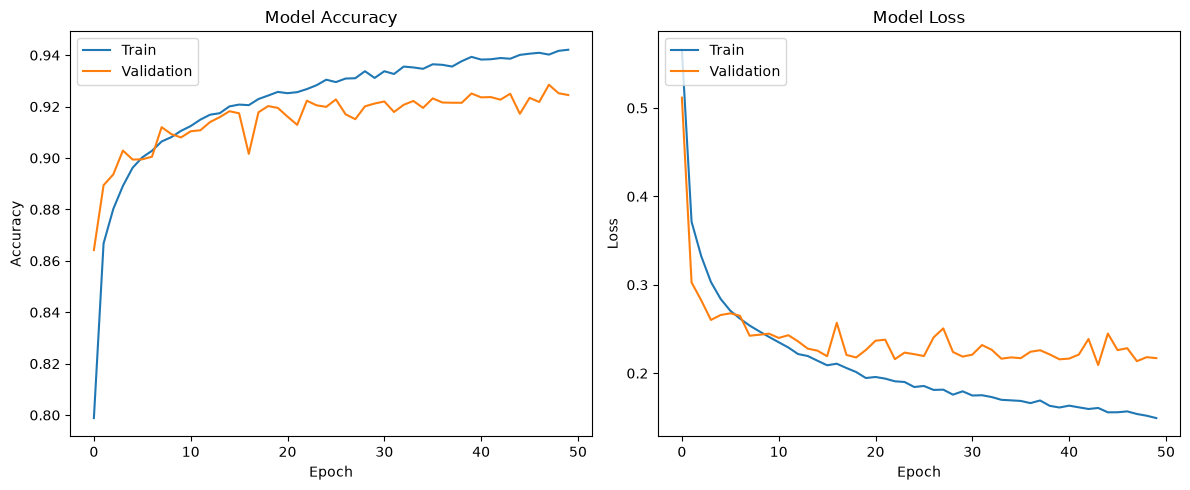

In [6]:
model = keras.Sequential([
    # First Conv2D + batch norm + maxpool
    keras.layers.Conv2D(32, (3,3), padding='same',input_shape=(28, 28, 1)),
    keras.layers.BatchNormalization(axis=-1),
    keras.layers.Activation(activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),
    # Second Conv2D + maxpool
    keras.layers.Conv2D(64, (3,3), padding="same", activation=tf.nn.relu),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.50),
    keras.layers.Dense(64, activation=tf.nn.relu),
    keras.layers.Dropout(0.30),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer="Adam", 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(train_images, train_labels, batch_size=128, 
                                        epochs=50, validation_data=(test_images, test_labels))

plot_history(history)

## <font color="red">แบบฝึกหัดที่ 1 เพิ่ม batch_normalisation</font>

จริงๆแล้วเราสามารถเพิ่มจำนวนครั้งที่จะใช้ batch norm ได้ด้วย
1. ก่อนจะทำการเพิ่มจำนวน batch norm จงดูรูปทรงของกราฟว่าเกิดอะไรขึ้นระหว่าง train กราฟ val มีลักษณะเป็นอย่างไร?
2. จงแก้ไขโมเดลโดยเพิ่ม batch norm ครั้งที่ 2 เข้าไปหลัง conv2d อันที่ 2
   1. อย่าลืมเอา activation ของ conv2d อันที่ 2 ออกไป
   2. เติม batch norm, axis=-1
   3. สร้างเลเยอร์ที่เป็น activation relu มาทดแทนอันที่ลบไป
   4. ทำการฝึก 
3. จงแก้ไขโมเดลโดยเพิ่ม batch norm ครั้งที่ 3 เข้าไปหลัง dense 64
   1. อย่าลืมเอา activation ของ Dense64 ออกไป
   2. เติม batch norm, axis=-1
   3. สร้างเลเยอร์ที่เป็น activation relu มาทดแทนอันที่ลบไป
   4. ทำการฝึก
4. ฝึกข้อที่ 3 ด้วย batch_size = 512 และสังเกตุว่ากราฟนั้นมีการเปลี่ยนแปลงอย่างไรบ้าง ลู่เข้าสู่จุดอิ่มตัวของ accuracy เร็วขึ้นหรือไม่? smooth มากขึ้นหรือไม่? แตกต่างจากข้อ 2 และ 3 อย่างไร

<font color="blue">พื้นที่สำหรับตอบคำถาม</font>

ข้อที่ 1
> the graph show that this model could be overfitting as the accuracy keep increasing, and loss keep decreasing  but for val_accuracy these ecpochs and it decrease and increase not always increaseing like accuracy, the same for val_loss.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,642 (397.04 KB)

 Trainable params: 101,514 (396.54 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.7456 - loss: 0.7133 - val_accuracy: 0.8150 - val_loss: 0.7045
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.8267 - loss: 0.4736 - val_accuracy: 0.8668 - val_loss: 0.3656
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.8456 - loss: 0.4224 - val_accuracy: 0.8762 - val_loss: 0.3359
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.8557 - loss: 0.3956 - val_accuracy: 0.8865 - val_loss: 0.3103
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.8608 - loss: 0.3810 - val_accuracy: 0.8841 - val_loss: 0.3115
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.8662 - loss: 0.3678 - val_accuracy: 0.8840 - val_loss: 0.3083
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.8702 - loss: 0.3559 - val_accuracy: 0.8906 - val_loss: 0.2924
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.8710 - loss: 0.3488 - 

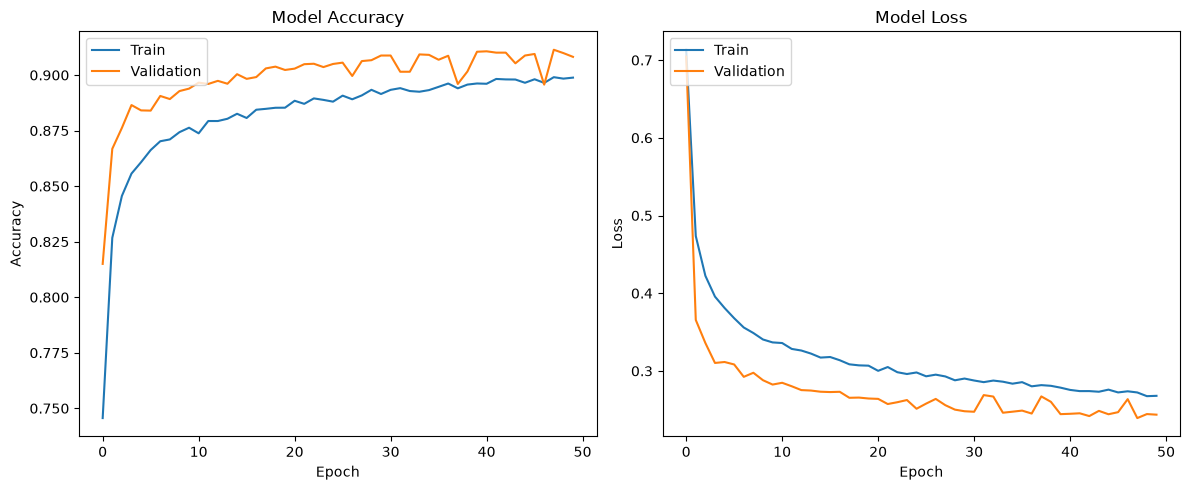

In [7]:
# โค้ดสำหรับแบบฝึก 1 ข้อที่ 2
model = keras.Sequential([
    # First Conv2D + batch norm + maxpool
    keras.layers.Conv2D(32, (3,3), padding='same',input_shape=(28, 28, 1)),
    keras.layers.BatchNormalization(axis=-1),
    keras.layers.Activation(activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),
    # Second Conv2D + maxpool
    # keras.layers.Conv2D(64, (3,3), padding="same", activation=tf.nn.relu),
    keras.layers.BatchNormalization(axis=-1),
    keras.layers.Activation(activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.50),
    keras.layers.Dense(64, activation=tf.nn.relu),
    keras.layers.Dropout(0.30),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer="Adam", 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(train_images, train_labels, batch_size=128, 
                                        epochs=50, validation_data=(test_images, test_labels))

plot_history(history)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,898 (398.04 KB)

 Trainable params: 101,642 (397.04 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.7858 - loss: 0.6160 - val_accuracy: 0.6673 - val_loss: 0.9805
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.8486 - loss: 0.4274 - val_accuracy: 0.8784 - val_loss: 0.3358
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.8610 - loss: 0.3854 - val_accuracy: 0.8800 - val_loss: 0.3289
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.8661 - loss: 0.3660 - val_accuracy: 0.8850 - val_loss: 0.3052
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.8724 - loss: 0.3520 - val_accuracy: 0.8957 - val_loss: 0.2898
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.8739 - loss: 0.3421 - val_accuracy: 0.8942 - val_loss: 0.2883
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.8789 - loss: 0.3347 - val_accuracy: 0.8958 - val_loss: 0.2832
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.8786 - loss: 0.3279 - 

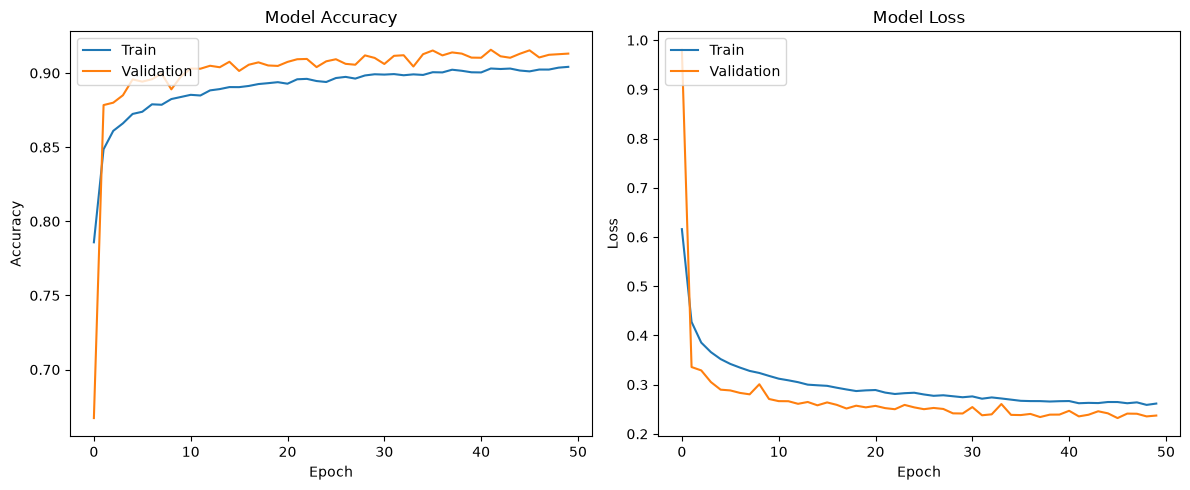

In [8]:
# โค้ดสำหรับแบบฝึก 1 ข้อที่ 3
model = keras.Sequential([
    # First Conv2D + batch norm + maxpool
    keras.layers.Conv2D(32, (3,3), padding='same',input_shape=(28, 28, 1)),
    keras.layers.BatchNormalization(axis=-1),
    keras.layers.Activation(activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),
    # Second Conv2D + maxpool
    # keras.layers.Conv2D(64, (3,3), padding="same", activation=tf.nn.relu),
    keras.layers.BatchNormalization(axis=-1),
    keras.layers.Activation(activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.50),
    keras.layers.Dense(64),
    keras.layers.BatchNormalization(axis=-1),
    keras.layers.Activation(activation="relu"),
    keras.layers.Dropout(0.30),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer="Adam", 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(train_images, train_labels, batch_size=128, 
                                        epochs=50, validation_data=(test_images, test_labels))

plot_history(history)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,898 (398.04 KB)

 Trainable params: 101,642 (397.04 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 23s 174ms/step - accuracy: 0.7213 - loss: 0.8307 - val_accuracy: 0.1000 - val_loss: 2.4246
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 19s 159ms/step - accuracy: 0.8231 - loss: 0.5084 - val_accuracy: 0.1000 - val_loss: 2.6518
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 173ms/step - accuracy: 0.8442 - loss: 0.4389 - val_accuracy: 0.1683 - val_loss: 2.3054
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 21s 177ms/step - accuracy: 0.8560 - loss: 0.4064 - val_accuracy: 0.5432 - val_loss: 1.2604
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 19s 158ms/step - accuracy: 0.8620 - loss: 0.3856 - val_accuracy: 0.7963 - val_loss: 0.5339
Epoch 6/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 170ms/step - accuracy: 0.8647 - loss: 0.3689 - val_accuracy: 0.8596 - val_loss: 0.3675
Epoch 7/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 19s 157ms/step - accuracy: 0.8700 - loss: 0.3607 - val_accuracy: 0.8646 - val_loss: 0.3557
Epoch 8/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 20s 171ms/step - accuracy: 0.8759 - loss: 0

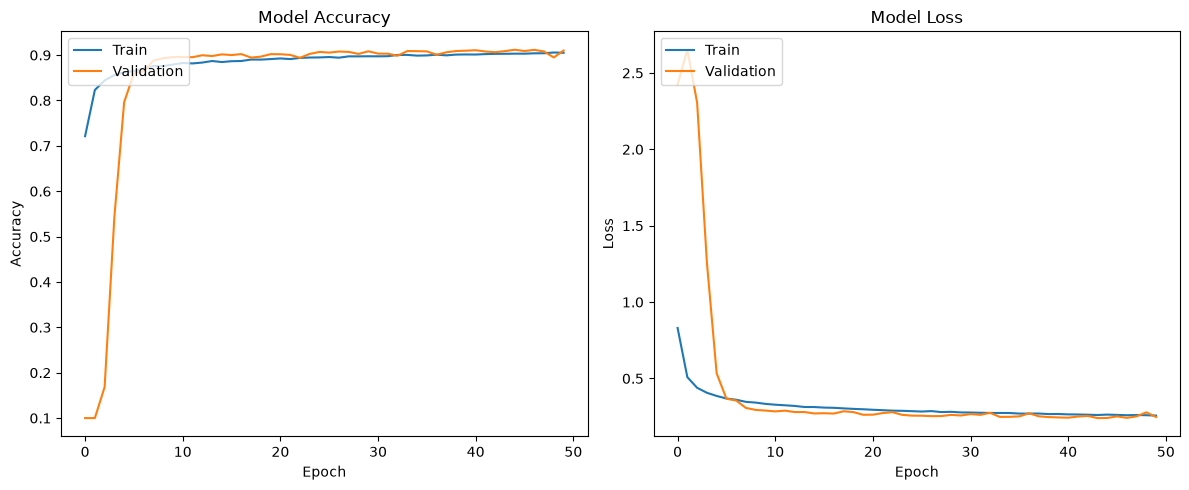

In [9]:
model = keras.Sequential([
    # First Conv2D + batch norm + maxpool
    keras.layers.Conv2D(32, (3,3), padding='same',input_shape=(28, 28, 1)),
    keras.layers.BatchNormalization(axis=-1),
    keras.layers.Activation(activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),
    # Second Conv2D + maxpool
    # keras.layers.Conv2D(64, (3,3), padding="same", activation=tf.nn.relu),
    keras.layers.BatchNormalization(axis=-1),
    keras.layers.Activation(activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.50),
    keras.layers.Dense(64),
    keras.layers.BatchNormalization(axis=-1),
    keras.layers.Activation(activation="relu"),
    keras.layers.Dropout(0.30),
    keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer="Adam", 
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(train_images, train_labels, batch_size=512, 
                                        epochs=50, validation_data=(test_images, test_labels))

plot_history(history)

<font color="blue">พื้นที่สำหรับตอบคำถาม</font>

ข้อที่ 4
> when changing the batch_size from 128 to 512, the graph of the model with batch_size 512 almost the same for the test data and train data. However, the model with one batch_size 128 is still a little better with 0.0031 more than the 512 batch_size model. Overall, the batch_size 512 is still better cause is smoother and better for all data either test or train data.
